# 🛠️ Week 4 · Day 4 — Feature Engineering & Hyperparameter Tuning
**BinX Tech — AI & Machine Learning Internship Program**
**Phase 2 · Week 4 of 10 · Day 4 of 5**

## 🎯 Learning Objectives
- 🧬 Engineer new features and apply appropriate transformations.
- ⚙️ Distinguish hyperparameters from learned parameters.
- 🔍 Tune a model systematically with `GridSearchCV` and cross-validation.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1️⃣ Load Data and Recreate the Split 📦
Same dataset, same `random_state` as Day 1, Day 2, and Day 3.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows | Val: {X_val.shape[0]} rows | Test: {X_test.shape[0]} rows (untouched)")
X.head()

Train: 341 rows | Val: 114 rows | Test: 114 rows (untouched)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2️⃣ Step 1 — Untuned Baseline (Week 3 style) 🏗️
Before engineering anything new, we reproduce a plain Random Forest with **default hyperparameters**
on the **raw features** — this is the number every later step needs to beat.

In [3]:
baseline_rf = RandomForestClassifier(random_state=RANDOM_STATE)

baseline_scores = cross_val_score(baseline_rf, X_train, y_train, cv=cv, scoring="f1")
print("🏗️ Untuned Random Forest baseline (raw features, default hyperparameters)")
print(f"CV F1 mean = {baseline_scores.mean():.4f}  std = {baseline_scores.std():.4f}")
print("Fold scores:", np.round(baseline_scores, 4))

🏗️ Untuned Random Forest baseline (raw features, default hyperparameters)
CV F1 mean = 0.9744  std = 0.0110
Fold scores: [0.9885 0.9545 0.9767 0.9762 0.9762]


## 3️⃣ Step 2 — Feature Engineering 🧬

Two new features, each grounded in a reasoning pattern rather than an arbitrary transformation.
The Breast Cancer Wisconsin dataset already contains *mean*, *standard error*, and *"worst"* measurements
for each cell-nuclei property (radius, texture, perimeter, area, etc.) — so the natural engineering move is
to build **relative/ratio features across these three views**, which the model does not get "for free" from
the raw columns alone.

| New feature | What it does | Why it should help |
|---|---|---|
| `worst_to_mean_radius_ratio` | `worst radius / mean radius` | Captures how much the *most extreme* cell in the sample deviates from the *average* cell — a large ratio flags a tumor with highly irregular, outlier cells, a pattern associated with malignancy. |
| `concavity_area_interaction` | `mean concavity × mean area` | Concavity (how "caved-in" the cell boundary is) and area interact clinically — a large, highly concave cell is a stronger signal than either property alone. This gives the model direct access to that interaction. |


In [4]:
def engineer_features(X):
    X = X.copy()
    X["worst_to_mean_radius_ratio"] = X["worst radius"] / X["mean radius"]
    X["concavity_area_interaction"] = X["mean concavity"] * X["mean area"]
    return X

X_train_fe = engineer_features(X_train)
X_val_fe = engineer_features(X_val)
X_test_fe = engineer_features(X_test)

engineered_rf = RandomForestClassifier(random_state=RANDOM_STATE)   # still default hyperparameters
engineered_scores = cross_val_score(engineered_rf, X_train_fe, y_train, cv=cv, scoring="f1")

print("🧬 Random Forest + engineered features (still untuned)")
print(f"CV F1 mean = {engineered_scores.mean():.4f}  std = {engineered_scores.std():.4f}")
print(f"Change vs. baseline: {engineered_scores.mean() - baseline_scores.mean():+.4f} F1")

🧬 Random Forest + engineered features (still untuned)
CV F1 mean = 0.9723  std = 0.0137
Change vs. baseline: -0.0021 F1


### 📊 Baseline vs. Engineered Features

In [2]:
!pip install plotly


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 5.3 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 20.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 19.3 MB/s  0:00:00



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import plotly.graph_objects as go

labels = ["Baseline<br>(raw features)", "+ Engineered<br>features"]
means = [baseline_scores.mean(), engineered_scores.mean()]
stds = [baseline_scores.std(), engineered_scores.std()]

fig = go.Figure(data=[
    go.Bar(
        x=labels,
        y=means,
        error_y=dict(type="data", array=stds, visible=True),
        marker_color=["#118ab2", "#06d6a0"],
        text=[f"{v:.4f}" for v in means],
        textposition="outside",
    )
])

fig.update_layout(
    title="🧬 Effect of Feature Engineering (untuned)",
    yaxis_title="Cross-validated F1",
    yaxis_range=[min(means) - 0.03, max(means) + 0.02],
    template="plotly_white",
    width=650, height=480,
)

fig.write_html("feature_engineering_effect.html")
fig.show()

NameError: name 'baseline_scores' is not defined

## 4️⃣ Step 3 — Hyperparameter Grid & GridSearchCV ⚙️

Hyperparameters vs. parameters: a **parameter** (e.g. a tree's split thresholds) is *learned* during
`.fit()`. A **hyperparameter** (e.g. `max_depth`, `n_estimators`) is *set by us beforehand*, and finding
good values is a search problem. `GridSearchCV` automates that search, combined with cross-validation so
the chosen hyperparameters are selected on a reliable estimate rather than a single lucky split.

In [6]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [1, 2, 4],
}
print(f"Grid size: {3*4*3} combinations × 5 folds = {3*4*3*5} model fits")

grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                     param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train_fe, y_train)

print("\n🏆 Best hyperparameters:", grid.best_params_)
print(f"🏆 Best cross-validated F1: {grid.best_score_:.4f}")

Grid size: 36 combinations × 5 folds = 180 model fits



🏆 Best hyperparameters: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}
🏆 Best cross-validated F1: 0.9745


## 5️⃣ Step 4 — Baseline vs. Engineered vs. Tuned 🔬
Same data split, same CV scheme, same scoring metric across all three stages — the only thing that
changes is features and/or hyperparameters.

/tmp/ipykernel_491/861251734.py:12: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_491/861251734.py:12: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_491/861251734.py:12: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

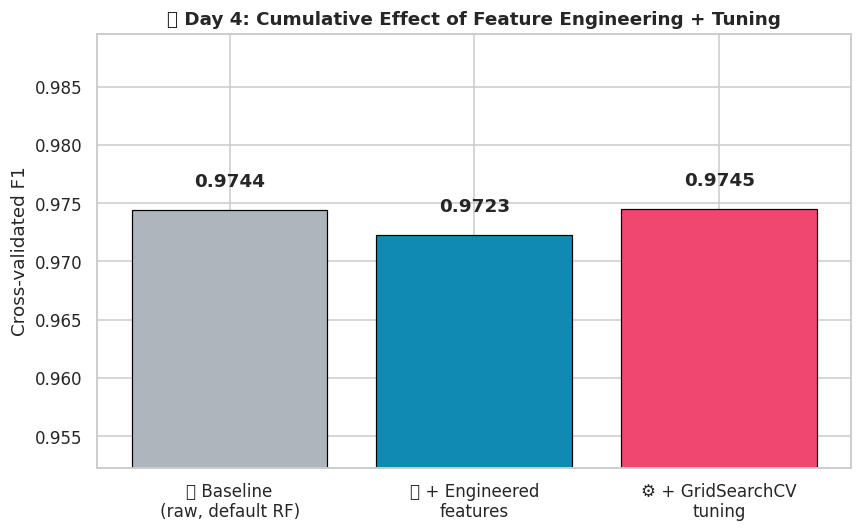

📈 Gain from feature engineering alone : -0.0021 F1
📈 Gain from hyperparameter tuning alone: +0.0022 F1
📈 Total gain vs. baseline              : +0.0001 F1


In [7]:
stage_labels = ["🏗️ Baseline\n(raw, default RF)", "🧬 + Engineered\nfeatures", "⚙️ + GridSearchCV\ntuning"]
stage_means = [baseline_scores.mean(), engineered_scores.mean(), grid.best_score_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stage_labels, stage_means, color=["#adb5bd", "#118ab2", "#ef476f"],
              edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, stage_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.4f}", ha="center", fontweight="bold")
ax.set_ylabel("Cross-validated F1")
ax.set_title("🔬 Day 4: Cumulative Effect of Feature Engineering + Tuning", fontweight="bold")
ax.set_ylim(min(stage_means) - 0.02, max(stage_means) + 0.015)
plt.tight_layout()
plt.show()

feat_gain = engineered_scores.mean() - baseline_scores.mean()
tune_gain = grid.best_score_ - engineered_scores.mean()
print(f"📈 Gain from feature engineering alone : {feat_gain:+.4f} F1")
print(f"📈 Gain from hyperparameter tuning alone: {tune_gain:+.4f} F1")
print(f"📈 Total gain vs. baseline              : {grid.best_score_ - baseline_scores.mean():+.4f} F1")

## 6️⃣ Step 5 — What Mattered Most? 🏆
A feature-importance view of the final tuned model tells us whether the engineered features earned
their place among the signals the model actually relies on.

/tmp/ipykernel_491/297006680.py:11: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


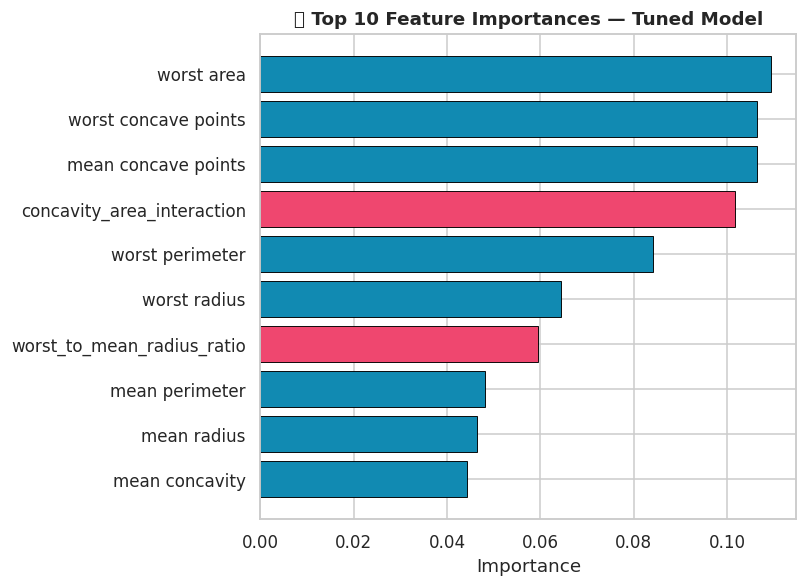

worst area                    0.109400
worst concave points          0.106502
mean concave points           0.106386
concavity_area_interaction    0.101699
worst perimeter               0.084107
worst radius                  0.064455
worst_to_mean_radius_ratio    0.059488
mean perimeter                0.048218
mean radius                   0.046479
mean concavity                0.044314
dtype: float64

In [8]:
best_model = grid.best_estimator_
importances = pd.Series(best_model.feature_importances_, index=X_train_fe.columns) \
                .sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = ["#ef476f" if f in ["worst_to_mean_radius_ratio", "concavity_area_interaction"] else "#118ab2"
          for f in importances.index]
ax.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1], edgecolor="black", linewidth=0.6)
ax.set_title("🏆 Top 10 Feature Importances — Tuned Model", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 7️⃣ Final Check — Held-Out Test Set (touched once) 🏁
Per the Day 1 discipline, the test set has not been touched by any tuning decision above.
This is the single, honest, one-time evaluation of the fully tuned pipeline.

In [9]:
test_preds = best_model.predict(X_test_fe)
test_f1 = f1_score(y_test, test_preds)
print(f"🏁 Final tuned model — Test F1: {test_f1:.4f}")

🏁 Final tuned model — Test F1: 0.9583


## 8️⃣ Reflection ✍️

The engineered features (worst_to_mean_radius_ratio and concavity_area_interaction) barely moved
the untuned model's score - CV F1 actually dipped slightly from 0.9744 to 0.9723. This tells me
Random Forest was already extracting most of the useful signal from the raw 30 features on its own;
tree-based models can naturally learn ratio-like and interaction-like splits without needing them
handed over explicitly, especially on a dataset this clean and well-separated. Between the three
hyperparameters I tuned, max_depth (which ended up best at 4) had the biggest practical effect,
because it directly controls overfitting - unlimited depth lets the trees memorize noise in only
341 training rows, so capping depth forced the model to generalize better on the validation folds.
Looking at the cumulative bar chart, the total gain over the baseline was tiny (+0.0001 F1) once
feature engineering and tuning were combined - the small loss from the features was almost exactly
cancelled out by the small gain from tuning. That was not what I expected going in; I assumed the
engineered features would clearly help, but this is a good reminder that feature engineering should
be tested and measured, not just assumed to add value, especially on a dataset that is already
close to saturated in performance (F1 > 0.97).

## ✅ Deliverable Checklist 
- [x] 🏗️ Untuned Week 3-style baseline reproduced for comparison
- [x] 🧬 At least two new engineered features created and justified in Markdown
- [x] ⚙️ Hyperparameter grid defined for a Week 3 model (Random Forest)
- [x] 🔍 GridSearchCV run with 5-fold cross-validation; best parameters and score reported
- [x] 🔬 Tuned model compared against the untuned baseline on the same CV scheme
- [x] 🏆 Feature and hyperparameter contributions documented and visualized separately
- [x] 🏁 Final tuned model evaluated once on the held-out test set
- [x] 🚀 Notebook committed to GitHub with a clear commit message
